In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def BPSKmod(Y):
    X=Y.copy()
    index0=[X[i]==0 for i in range(X.shape[0])]
    index1=[X[i]==1 for i in range(X.shape[0])]
    X[index0]=1
    X[index1]=-1
    return X

def uTH(Y):
    X=Y.copy()
    index0=X<0.5
    index1=X>=0.5
    X[index0]=0
    X[index1]=1
    return X

In [3]:
m=10000 # number of training examples.
n=32 # codeword size.
std=1 # standard deviation
testDataSplit=0.1

In [ ]:
Y=np.random.randint(low=0,high=2,size=(m,n))
X=BPSKmod(Y)+np.random.normal(0,std,size=(m,n))
iTest=[i for i in range( int(testDataSplit*X.shape[0]) )]
iTrain=[i for i in range( int((1-testDataSplit)*X.shape[0]) )]
Xtr=X[iTrain]
Ytr=Y[iTrain]

Xte=X[iTest]
Yte=Y[iTest]

In [5]:
noOfExamples=10
def evalModel(model):
    print(model.evaluate(Xte,Yte,verbose=2))
    for i in range(noOfExamples):
        index=np.random.randint(low=0,high=Xte.shape[0])
        Yte_P=model.predict(Xte)
        print('Actual Value -> ',uTH(Yte_P[index]))
        print('Predicted Value -> ',Yte[index])
        print('--------------------')

In [6]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(2*Xtr.shape[1],activation='tanh'),
    tf.keras.layers.Dense(2*Xtr.shape[1],activation='tanh'),
    tf.keras.layers.Dense(2*Xtr.shape[1],activation='tanh'),
    tf.keras.layers.Dense(Xtr.shape[1],activation='sigmoid')
])
model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
              metrics=['categorical_accuracy'])
model.fit(Xtr,Ytr,epochs=100)
evalModel(model)

Epoch 1/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - categorical_accuracy: 0.0399 - loss: 0.1835
Epoch 2/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.0607 - loss: 0.1437
Epoch 3/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.0671 - loss: 0.1323
Epoch 4/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.0649 - loss: 0.1280
Epoch 5/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.0710 - loss: 0.1253
Epoch 6/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.0680 - loss: 0.1232
Epoch 7/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.0681 - loss: 0.1217
Epoch 8/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_accuracy: 0.0654 - loss: 0.1205
Epoch 9/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - categorical_accuracy: 0.0653 - loss: 0.1194
Epoch 10/100
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - categorical_accuracy: 0.0683 - loss: 0.1185
Epoch 11/

In [ ]:
Yte_P=model.predict(Xte)
Yte_P[Yte_P<=0.5]=0
Yte_P[Yte_P>0.5]=1
total=Yte_P.shape[0]
rcnt=0

for i in range(Yte_P.shape[0]):
    for j in range(Yte_P.shape[1]):
        if Yte_P[i][j]!=Yte[i][j]:
            rcnt+=1
            break
print('Accuracy ~ %lf'%(1-rcnt/total))
print(model.evaluate(Xte,Yte,verbose=2))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy ~ 0.008000
32/32 - 0s - 3ms/step - categorical_accuracy: 0.0690 - loss: 0.1042
[0.10418404638767242, 0.0689999982714653]


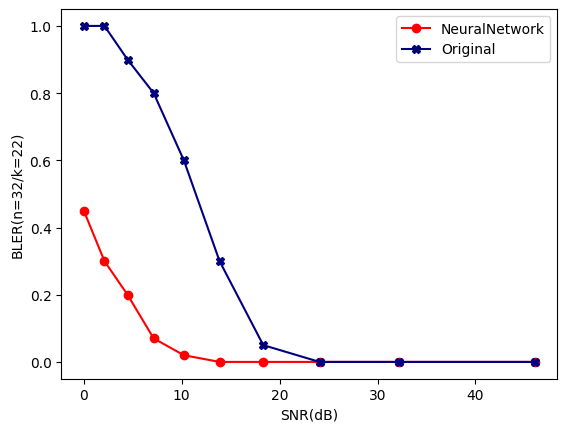

In [ ]:
# SNR vs BLER gaph.

std = np.array([(i+1)/10 for i in range(10)])
SNR = 10*np.log(1/std**2)

blerInvNN = np.array([1,1,1,1,1,0.98,0.93,0.80,0.7,0.55]) # BLER INV = How many blocks match (rate)
blerInvOrig = np.array([1,1,1,0.95,0.7,0.4,0.2,0.1,0,0])
blerNN = 1-blerInvNN
blerOrig = 1-blerInvOrig

plt.plot(SNR, blerNN, marker='o',color='red')
plt.plot(SNR, blerOrig, marker='X',color='navy')

plt.xlabel('SNR(dB)')
plt.ylabel('BLER(n=32/k=22)') # n=32 and k=22 is wrong for this example
plt.legend(['NeuralNetwork','Original'])
plt.savefig('LDPC_NN.png')